# Random Forest Benchmark for Irrigation Classification

In [1]:
# %% Imports
import os
import glob
import numpy as np
import rasterio
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    accuracy_score, jaccard_score, f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib
import json

In [6]:
# %% Configuration
base_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/'
TRAIN_DIR = os.path.join(base_dir,'training_chips')
VAL_DIR = os.path.join(base_dir,'validation_chips')
OUTPUT_DIR = 'rf_outputs'

CLASS_NAMES = ["Water", "non-ag", "Irrigated", "Rainfed"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(42)

In [7]:
# %% Find training chips
train_images = sorted(glob.glob(os.path.join(TRAIN_DIR, '*_merged.tif')))
print(f"Found {len(train_images)} training chips")
print(f"Example: {train_images[0]}")

# %% Load ONE chip to check structure
test_img_path = train_images[0]
test_mask_path = test_img_path.replace('_merged.tif', '.mask.tif')

with rasterio.open(test_img_path) as src:
    test_img = src.read()
    print(f"Image shape: {test_img.shape}")  # Should be (18, H, W)
    print(f"Image dtype: {test_img.dtype}")

with rasterio.open(test_mask_path) as src:
    test_mask = src.read(1)
    print(f"Mask shape: {test_mask.shape}")  # Should be (H, W)
    print(f"Unique mask values: {np.unique(test_mask)}")

Found 3058 training chips
Example: /discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/chip_003_062_merged.tif
Image shape: (18, 224, 224)
Image dtype: int16
Mask shape: (224, 224)
Unique mask values: [0 1 2 3]


In [8]:
# %% Load all TRAINING chips
all_X_train = []
all_y_train = []

for img_path in tqdm(train_images, desc="Loading training"):
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    
    if not os.path.exists(mask_path):
        print(f"No mask for {img_path}")
        continue
    
    # Read
    with rasterio.open(img_path) as src:
        img = src.read()  # (18, H, W)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)  # (H, W)
    
    # Reshape to pixels: (18, H, W) -> (H*W, 18)
    n_bands, H, W = img.shape
    X = img.reshape(n_bands, -1).T  # (H*W, 18)
    y = mask.flatten()  # (H*W,)
    
    # Keep valid pixels only (classes 0-3)
    valid = (y >= 0) & (y < 4)
    X = X[valid]
    y = y[valid]
    
    all_X_train.append(X)
    all_y_train.append(y)

X_train = np.concatenate(all_X_train)
y_train = np.concatenate(all_y_train)

print(f"\nTraining data: {X_train.shape[0]:,} pixels, {X_train.shape[1]} features")

Loading training: 100%|██████████| 3058/3058 [02:13<00:00, 22.98it/s]



Training data: 153,438,208 pixels, 18 features


In [9]:
# %% Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Training class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  {CLASS_NAMES[int(cls)]}: {cnt:,} ({100*cnt/len(y_train):.1f}%)")

Training class distribution:
  Water: 16,911,355 (11.0%)
  non-ag: 37,683,621 (24.6%)
  Irrigated: 27,713,026 (18.1%)
  Rainfed: 71,130,206 (46.4%)


In [11]:
# %% Load all VALIDATION chips
val_images = sorted(glob.glob(os.path.join(VAL_DIR, '*_merged.tif')))
print(f"Found {len(val_images)} validation chips")

all_X_val = []
all_y_val = []

for img_path in tqdm(val_images, desc="Loading validation"):
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    
    if not os.path.exists(mask_path):
        continue
    
    with rasterio.open(img_path) as src:
        img = src.read()
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    n_bands, H, W = img.shape
    X = img.reshape(n_bands, -1).T
    y = mask.flatten()
    
    valid = (y >= 0) & (y < 4)
    X = X[valid]
    y = y[valid]
    
    all_X_val.append(X)
    all_y_val.append(y)

X_val = np.concatenate(all_X_val)
y_val = np.concatenate(all_y_val)

print(f"\nValidation data: {X_val.shape[0]:,} pixels")

Found 766 validation chips


Loading validation: 100%|██████████| 766/766 [00:29<00:00, 25.96it/s]



Validation data: 38,434,816 pixels


In [14]:
# %% (Optional) Subsample training data if too large
MAX_TRAIN_PIXELS = 80_000_000

if len(y_train) > MAX_TRAIN_PIXELS:
    print(f"Subsampling: {len(y_train):,} -> {MAX_TRAIN_PIXELS:,}")
    idx = np.random.choice(len(y_train), MAX_TRAIN_PIXELS, replace=False)
    X_train = X_train[idx]
    y_train = y_train[idx]

# %% Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training...")
rf.fit(X_train, y_train)
print("Done!")

Training...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:  1.5min


Done!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.4min finished


Predicting...


[Parallel(n_jobs=46)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=46)]: Done 108 tasks      | elapsed:   29.3s
[Parallel(n_jobs=46)]: Done 200 out of 200 | elapsed:   47.7s finished


RESULTS
Accuracy:     0.6717
Mean Jaccard: 0.4910
Mean F1:      0.6572

Per-class Jaccard (IoU):
  Water: 0.5000
  non-ag: 0.4748
  Irrigated: 0.4267
  Rainfed: 0.5624

              precision    recall  f1-score   support

       Water     0.6336    0.7034    0.6667   4650027
      non-ag     0.6373    0.6506    0.6439   9391900
   Irrigated     0.5754    0.6227    0.5981   6861895
     Rainfed     0.7481    0.6937    0.7199  17530994

    accuracy                         0.6717  38434816
   macro avg     0.6486    0.6676    0.6572  38434816
weighted avg     0.6763    0.6717    0.6731  38434816



<Figure size 800x600 with 0 Axes>

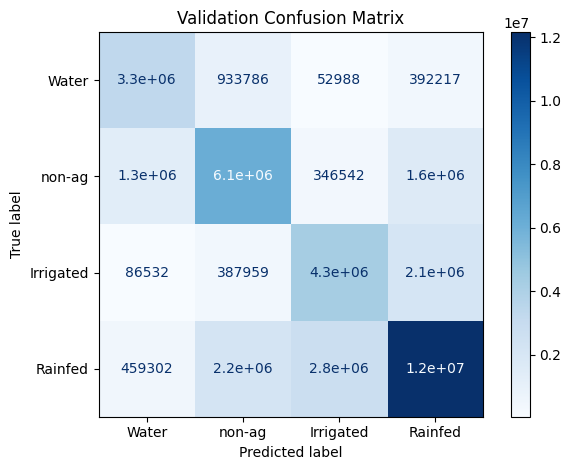

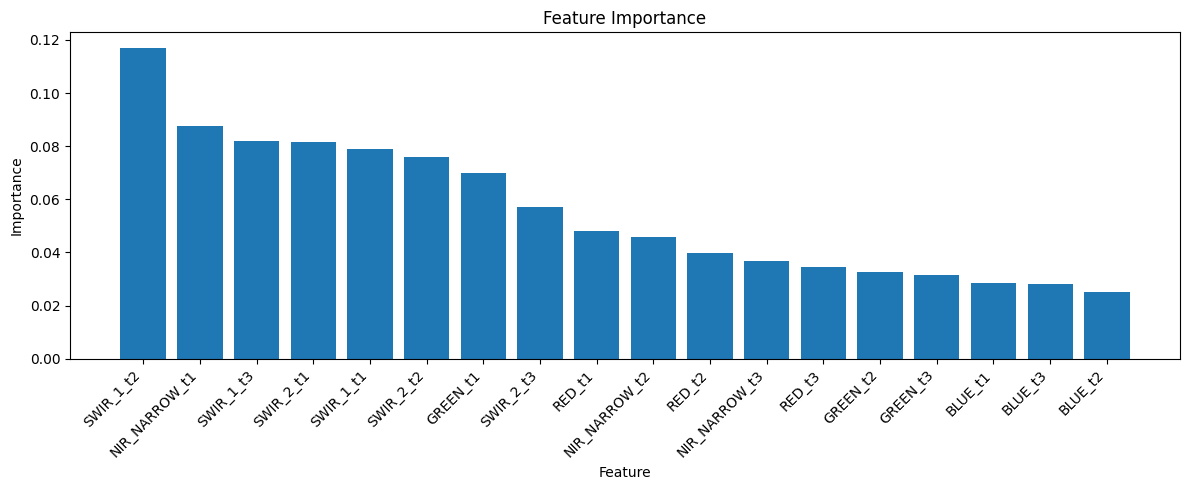


Saved to rf_outputs/


In [15]:
# %% Predict on validation
print("Predicting...")
y_pred = rf.predict(X_val)

# %% Calculate metrics
acc = accuracy_score(y_val, y_pred)
jaccard = jaccard_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

print("=" * 50)
print("RESULTS")
print("=" * 50)
print(f"Accuracy:     {acc:.4f}")
print(f"Mean Jaccard: {jaccard:.4f}")
print(f"Mean F1:      {f1:.4f}")

# %% Per-class Jaccard
per_class_jaccard = jaccard_score(y_val, y_pred, average=None)

print("\nPer-class Jaccard (IoU):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {per_class_jaccard[i]:.4f}")

# %% Classification report
print("\n" + classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

# %% Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()

# %% Feature importance
band_names = ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"]
feature_names = [f"{b}_t{t+1}" for t in range(3) for b in band_names]

importance = rf.feature_importances_

plt.figure(figsize=(12, 5))
sorted_idx = np.argsort(importance)[::-1]
plt.bar(range(len(importance)), importance[sorted_idx])
plt.xticks(range(len(importance)), [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=300)
plt.show()

# %% Save model and results
joblib.dump(rf, os.path.join(OUTPUT_DIR, 'rf_model.joblib'))

results = {
    'accuracy': float(acc),
    'mean_jaccard': float(jaccard),
    'mean_f1': float(f1),
    'per_class_jaccard': {CLASS_NAMES[i]: float(per_class_jaccard[i]) for i in range(4)},
    'train_pixels': int(len(y_train)),
    'val_pixels': int(len(y_val)),
}

with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nSaved to {OUTPUT_DIR}/")